# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)
3. Can linear regression be used for classification? Explain why, or why not.
4. What are signs that your linear model is over-fitting?
5. Clearly explain multi-colinearity using the two-stage least squares technique.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the slope coefficient in a linear regression?
8. Compare the train/test split and $k$-fold cross validation.
9. How is the $k$ in $k$-fold cross validation typically selected?

*Answers - Q1:*

1. A model is linear when there is a linear relationship between the target variable and the feature variables. For instance, the form `y = mx + b` is a linear relationship, where `y` would be the predictions, `x` would be the one explanatory variable (which has a weight `m`), and there is a constant `b`. So a linear model must be linear in the parameters.
2. The coefficient for a dummy variable is interpreted as how much the prediction changes compared to the reference group, which is the category that is left out when doing one-hot encoding. 
3. Yes, linear regression can be used for classification by assigning the numerical output to a categorical class based on thresholds. For instance, in the case of binary classification, numerical values < 0.5 could be class 1 while values > 0.5 could be class 2.
4. A sign of overfitting is when the model performs very well on the training set but poorly on the test set. This is an indication that the model is not able to generalize to the patterns of the data.
5. Multicollinearity means that one predictor can be strongly explained by other predictors. Using the 2-stage least-squares technique:
    * Stage 1 - try predicting one vaiable using the other variables, and if that works, it means those variables are highly related.
    * Stage 2 - when regression is run to predict y, the model would have touble figuring out which variable is actually responsible for the effect, because they contain almost the same information.
6. One way to incorporate nonlinear relationships between the target and feature variables is to transform the variables (like log(x), x^2, etc.). Even though these are nonlinear transformations of x, the model is still linear in the coefficients.
7. The slope coeficient represents how much the predicted value of y changes when the x increases by one unit (holidng everything else constant).
8. A train/test split divides the data once into two parts, one for training the data and one for testing it. In k-fold cross validation, the data is split into k smaller groups and trained k times, each iteration using a different group as the test set. Usually, k-fold CV is more reliable for estimating performance since the model is tested and trained multiple times on different parts of the data, and all those results are averaged.
9. The k is usually chosen based on what works well in practice, since if k is too small, the estimate cna be noisy, while if k is too large, it can take much longer to run.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression  
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import PolynomialFeatures

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

                     Price  Review Scores Rating
Neighbourhood                                   
Bronx            75.195349             91.706977
Brooklyn        125.246287             92.353653
Manhattan       178.339252             91.804071
Queens           96.813452             91.505711
Staten Island    95.516129             90.776596


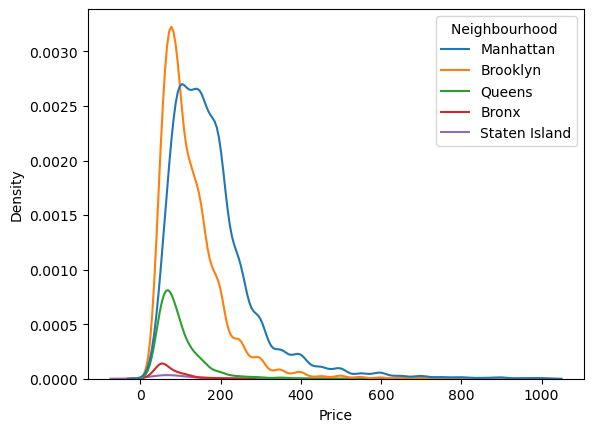

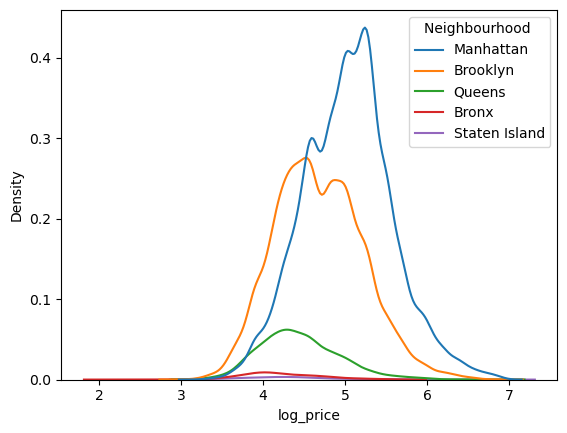

In [21]:
### 2.1
df = pd.read_csv("./data/airbnb_hw.csv")
df = df.dropna()

df["Price"] = pd.to_numeric(df["Price"], errors="coerce")
df["Review_Score"] = pd.to_numeric(df["Review Scores Rating"], errors="coerce")
group_means = df.groupby("Neighbourhood ")[["Price", "Review Scores Rating"]].mean()
print(group_means)  # The most expensive bourough on average is Manhattan

df["log_price"] = np.log(df["Price"])
sns.kdeplot(data=df, x="Price", hue="Neighbourhood ")
plt.show()
sns.kdeplot(data=df, x="log_price", hue="Neighbourhood ")
plt.show()

In [22]:
### 2.2
df = df.dropna()
df_clean = pd.get_dummies(df["Neighbourhood "], drop_first=True)
X2 = df_clean    
y = df["Price"]
model2 = LinearRegression()
model2.fit(X2, y)
print(f'Model intercept: {model2.intercept_}')
pd.DataFrame({'variable':model2.feature_names_in_, 'coefficient':model2.coef_ })

Model intercept: 75.19534883720976


,variable,coefficient
0,Brooklyn,50.050938
1,Manhattan,103.143903
2,Queens,21.618103
3,Staten Island,20.320780


Since I used one-hot encoding with drop_first=True, one neighborhood is treated as the baseline. In this case, the missing/omitted category is Bronx. So, the intercept (75.19) represents the average price in the Bronx, and each coefficient represents the difference in average price between that neighborhood and the Bronx. Adding each coefficient to the intercept reproduces the group means.

In [23]:
### 2.3
X3 = df[["Review_Score"]] 
y = df["Price"]
model3 = LinearRegression()
model3.fit(X3,y)
print(f'Model intercept: {model3.intercept_}')
pd.DataFrame({'variable':model3.feature_names_in_, 'coefficient':model3.coef_ })

Model intercept: 59.79915240941365


,variable,coefficient
0,Review_Score,0.989087


For each 1-point increase in review rating, the price is expected to increase by about $0.99. This indicates a positive relationship between review scores and price, but the effect is very small, suggesting that review ratings have only a minor influence on price.

In [24]:
### 2.4
df_clean = pd.get_dummies(df["Neighbourhood "], drop_first=True)
X4 = pd.concat([df_clean, df["Review_Score"]], axis=1)
y = df["Price"]
model4 = LinearRegression()
model4.fit(X4, y)
print(f"Model intercept: {model4.intercept_}")
pd.DataFrame({'variable':model4.feature_names_in_, 'coefficient':model4.coef_ })

Model intercept: -20.44010758994986


,variable,coefficient
0,Brooklyn,49.384824
1,Manhattan,103.054355
2,Queens,21.827991
3,Staten Island,20.721643
4,Review_Score,1.042837


The Review_Score coefficient increased slightly (from ~0.99 → ~1.04) meaning the relationship between review score and price becomes slightly stronger after controlling for neighborhood. However the neighborhood averages were very similar so those stayed about the same.

In [25]:
### 2.5
df_dummies = pd.get_dummies(df["Neighbourhood "], drop_first=False)
X5 = df_dummies.multiply(df["Review_Score"], axis=0)  
y = df["Price"]
model5 = LinearRegression(fit_intercept=False) 
model5.fit(X5, y)

pd.DataFrame({'neighbourhood': model5.feature_names_in_, 'slope': model5.coef_})

,neighbourhood,slope
0,Bronx,0.818362
1,Brooklyn,1.354294
2,Manhattan,1.934956
3,Queens,1.051472
4,Staten Island,1.040852


The slopes are not identical across neighborhoods, as Manhattan has the largest slope, while the Bronx has the smallest. This indicates that the relationship between review scores and price varies by neighborhood, though the slopes are all positive and relatively similar in magnitude (roughly between $0.8 and $1.9 per point).

In [26]:
### 2.6
y = df["Price"]

kfold = KFold(n_splits=10, shuffle=True, random_state=100)

cv_mse_3 = -cross_val_score(model3, X3, y, cv=kfold, scoring="neg_mean_squared_error")
cv_mse_4 = -cross_val_score(model4, X4, y, cv=kfold, scoring="neg_mean_squared_error")
cv_mse_5 = -cross_val_score(model5, X5, y, cv=kfold, scoring="neg_mean_squared_error")

print("Model 3 CV:\n")
print("Fold scores:", cv_mse_3)
print("Mean score:", np.mean(cv_mse_3))
print("Median score:", np.median(cv_mse_3))
print("Std dev:", np.std(cv_mse_3))
print("\n")

print("Model 4 CV:\n")
print("Fold scores:", cv_mse_4)
print("Mean score:", np.mean(cv_mse_4))
print("Median score:", np.median(cv_mse_4))
print("Std dev:", np.std(cv_mse_4))
print("\n")

print("Model 5 CV:\n")
print("Fold scores:", cv_mse_5)
print("Mean score:", np.mean(cv_mse_5))
print("Median score:", np.median(cv_mse_5))
print("Std dev:", np.std(cv_mse_5))               

Model 3 CV:

Fold scores: [10515.75658353  9412.17529715  9496.79582312 10596.29709712
  9335.40283044  9807.44558808 10058.32059927 10111.80855442
  9604.40168459 10497.10084211]
Mean score: 9943.55048998295
Median score: 9932.883093676825
Std dev: 456.8083026217036


Model 4 CV:

Fold scores: [9484.12479033 8436.52688321 8630.49057839 9815.03873663 8459.21022005
 8888.73792584 9038.47361356 9166.54640568 8582.06790874 9562.44912688]
Mean score: 9006.366618931188
Median score: 8963.605769702244
Std dev: 466.62252357937825


Model 5 CV:

Fold scores: [9486.64032777 8458.28609405 8705.10275628 9861.80315038 8457.22415534
 8900.90513101 9096.30493909 9229.54050468 8579.18305415 9592.83882611]
Mean score: 9036.782893888256
Median score: 8998.605035052584
Std dev: 473.4285243724268


**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`. 
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64


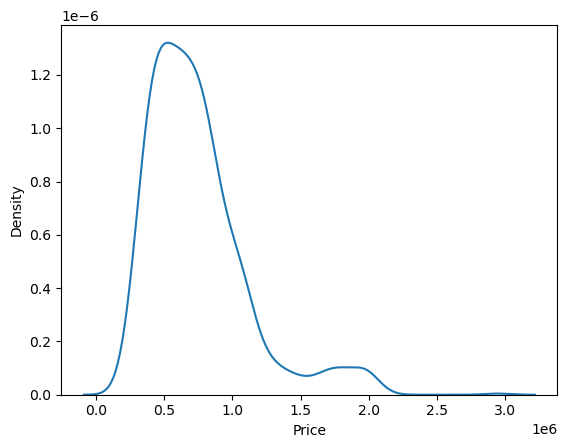

           count          mean            std       min       25%        50%  \
Body_Type                                                                      
crossover   21.0  7.050952e+05   72849.780207  608000.0  638000.0   706000.0   
hatchback  484.0  5.339773e+05  173086.729837  188000.0  401750.0   509000.0   
muv         38.0  6.264211e+05  184093.488526  328000.0  489750.0   621500.0   
sedan      227.0  8.097841e+05  286736.770092  368000.0  598000.0   772000.0   
suv        206.0  1.176495e+06  417479.028217  559000.0  860000.0  1065000.0   

                 75%        max  
Body_Type                        
crossover   749000.0   883000.0  
hatchback   661000.0  1107000.0  
muv         738500.0  1091000.0  
sedan       968500.0  2941000.0  
suv        1491250.0  2100000.0  


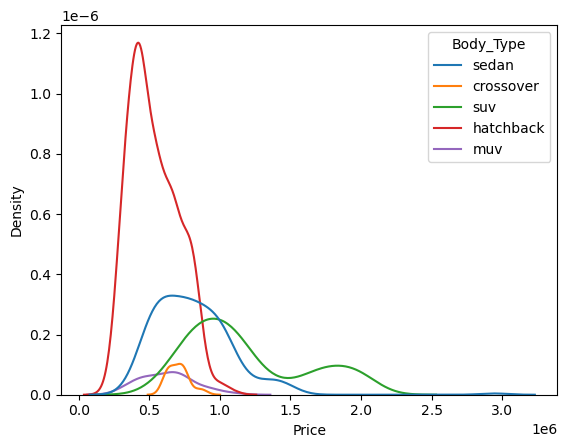

In [27]:
### 3.1 
df = pd.read_csv("./data/cars_hw.csv")
print(df["Price"].describe())
sns.kdeplot(data=df, x="Price")
plt.show()
print(df["Price"].groupby(df["Body_Type"]).describe())
sns.kdeplot(data=df, x="Price", hue="Body_Type")
plt.show()   
# suv's and then sedans are most expensive; sedans have the highest variance followed by suvs

In [28]:
### 3.2 
X = df[['Seating_Capacity']]
y = df['Price']
model = LinearRegression() 
model.fit(X, y)
print(f'Slope coefficient: {model.coef_[0]}')

Slope coefficient: 59267.998036721714


The slope coefficient is ~59268, which indicates that price increases by ~59268 rupees for every unit increase in seating_capacity.

   seating_capacity         slope
0                 5  5.464839e+05
1                 6  1.456000e+06
2                 7  7.359487e+05
3                 8  2.718000e+05


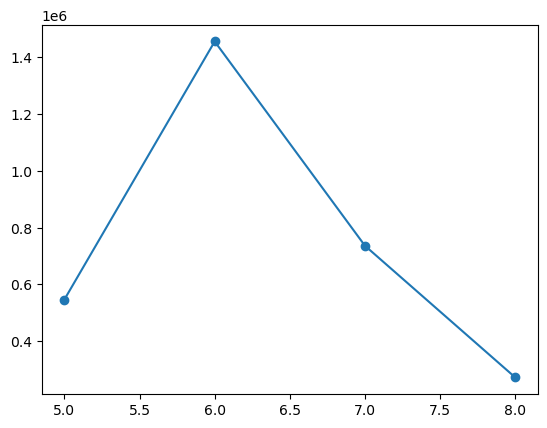

In [29]:
X = pd.get_dummies(df["Seating_Capacity"], drop_first=True)
y = df['Price']
model = LinearRegression()
model.fit(X, y) 
coef_df = pd.DataFrame({'seating_capacity': X.columns, 'slope': model.coef_})
print(coef_df)
plt.plot(coef_df['seating_capacity'], coef_df['slope'], marker='o')

The differences in price are not linear in the number of seats because the slope coefficients don't follow a linear pattern; for instance, the slope increases for 6 seats and then drops back down again for 7 seats and drops even more for 8 seats.

In [ ]:
### 3.3

df["Age"] = 2026 - df["Make_Year"]

X = df[["Age"]]
y = df["Price"]

cv = KFold(n_splits=10, shuffle=True, random_state=42)

results = []

for degree in range(1,11):
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly = poly.fit_transform(X)
    
    model = LinearRegression()
    scores = cross_val_score(model, X_poly, y, cv=cv, scoring="neg_mean_squared_error")
    
    mean_mse = -scores.mean()
    results.append((degree, mean_mse))
    
results_df = pd.DataFrame(results, columns=["degree", "cv_mse"])
print(results_df)

best_degree = results_df.loc[results_df["cv_mse"].idxmin(), "degree"]
print("Best degree:", best_degree) # The optimal number is 9 becaue it resulted in the lowest MSE.

   degree        cv_mse
0       1  9.737725e+10
1       2  9.739571e+10
2       3  9.674320e+10
3       4  9.622504e+10
4       5  9.526504e+10
5       6  9.535896e+10
6       7  9.468897e+10
7       8  9.387743e+10
8       9  9.339534e+10
9      10  9.349837e+10
Best degree: 9


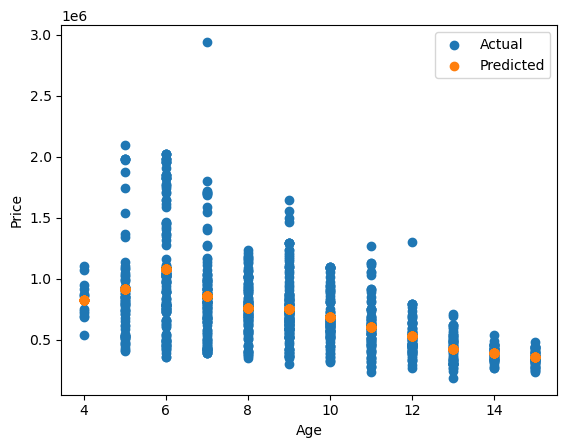

In [31]:
### 3.4
degree = best_degree  

poly = PolynomialFeatures(degree=degree, include_bias=False)
X_poly = poly.fit_transform(df[["Age"]])

model = LinearRegression()
model.fit(X_poly, df["Price"])

df["predicted_price"] = model.predict(X_poly)

plt.scatter(df["Age"], df["Price"], label="Actual")
plt.scatter(df["Age"], df["predicted_price"], label="Predicted")
plt.xlabel("Age")
plt.ylabel("Price")
plt.legend()
plt.show()

Yes, the model seems to capture the general decreasing relationship between price and age, but the predicted values do not capture the full spread of the data which vary widely with age.

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1. 
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models. 
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


In [32]:
### 4.1

df = pd.read_csv("./data/heart_hw.csv")
df.head()

survival_rates = df.groupby("transplant")["y"].mean()
print(survival_rates)

ate = survival_rates["treatment"] - survival_rates["control"]
print("ATE:", ate) # The ATE on three-year survival is ~0.23

transplant
control      0.117647
treatment    0.347826
Name: y, dtype: float64
ATE: 0.23017902813299232


In [33]:
### 4.2
X2 = pd.get_dummies(df["transplant"], drop_first=True)
y = df["y"]
model2 = LinearRegression()
model2.fit(X2, y)
print("Model intercept:", model2.intercept_)
print("Transplant coefficient:", model2.coef_[0])

Model intercept: 0.11764705882352933
Transplant coefficient: 0.23017902813299243


The intercept represents the survival rate in the control group, while the transplant coefficient represents the ATE. These values match the results from part 1.

In [34]:
### 4.3
X3 = pd.concat([pd.get_dummies(df["transplant"], drop_first=True), df[["age"]]], axis=1)
y = df["y"]

model3 = LinearRegression()
model3.fit(X3, y)

print("Model intercept:", model3.intercept_)
print(pd.DataFrame({"variable": model3.feature_names_in_, "coef": model3.coef_}))


Model intercept: 0.7019569721740946
    variable      coef
0  treatment  0.264702
1        age -0.013607


The intercept represents the predicted probability of survival for a control group patient at age 0. The transplant coefficient represents the change in survival probability holding age constant, specifically an increase of ~26.5 percentage points. The age coefficient represents the change in survival probability holding transplant status constant.

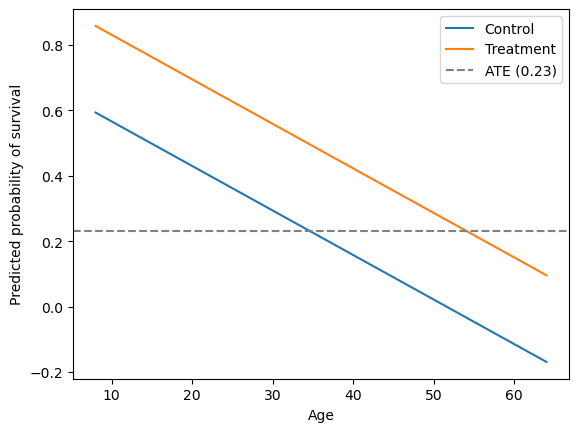

In [35]:
age_range = np.linspace(df["age"].min(), df["age"].max(), 100)
control_df = pd.DataFrame({"treatment": 0, "age": age_range})
treatment_df = pd.DataFrame({"treatment": 1, "age": age_range})
plt.plot(age_range, model3.predict(control_df), label="Control")
plt.plot(age_range, model3.predict(treatment_df), label="Treatment")
plt.axhline(ate, linestyle="--", color="gray", label=f"ATE ({ate:.2f})")
plt.xlabel("Age")
plt.ylabel("Predicted probability of survival")
plt.legend()
plt.show() 

For younger patients (roughly under ~35), the treatment line is above the ATE dashed line, meaning the ATE underestimates the absolute survival probability of transplant recipients in that range. For older patients (roughly over ~35), the treatment line falls below the ATE, meaning the ATE overestimates it.

Model intercept: 0.3548651752994586
          variable      coef
0        treatment  0.907751
1              age -0.005524
2  treatment_x_age -0.014591


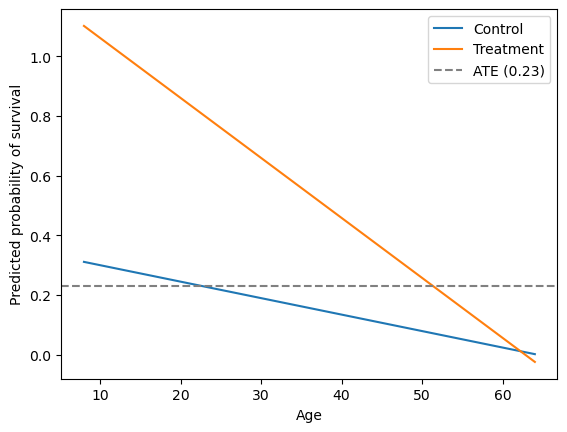

In [36]:
### 4.4
X4 = X3.copy()
X4["treatment_x_age"] = X4["treatment"] * X4["age"]

model4 = LinearRegression()
model4.fit(X4, y)

print("Model intercept:", model4.intercept_)
print(pd.DataFrame({"variable": model4.feature_names_in_, "coef": model4.coef_}))

control_df4 = pd.DataFrame({"treatment": 0, "age": age_range, "treatment_x_age": 0})
treatment_df4 = pd.DataFrame({"treatment": 1, "age": age_range, "treatment_x_age": age_range})

plt.plot(age_range, model4.predict(control_df4), label="Control")
plt.plot(age_range, model4.predict(treatment_df4), label="Treatment")
plt.axhline(ate, linestyle="--", color="gray", label=f"ATE ({ate:.2f})")
plt.xlabel("Age")
plt.ylabel("Predicted probability of survival")
plt.legend()
plt.show()

The lines are no longer parallel and the treatment line is much steeper than the control line. For young patients, the gap between the lines is very wide, which could indicate that the benefit of treatment is large. As age increases, the two lines converge, meeting around age ~60, which is where the transplant doesn't seem to provide a clear benefit. The negative coefficient for the interaction of age and treatment also indicates that each additional year of age reduces the benefit of the transplant slightly, so the pattern is that the treatment effect is decreasing in age.

In [37]:
kfold = KFold(n_splits=10, shuffle=True, random_state=100)

cv_mse_2 = -cross_val_score(model2, X2, y, cv=kfold, scoring="neg_mean_squared_error")
cv_mse_3 = -cross_val_score(model3, X3, y, cv=kfold, scoring="neg_mean_squared_error")
cv_mse_4 = -cross_val_score(model4, X4, y, cv=kfold, scoring="neg_mean_squared_error")

print("Model 2 CV:\n")
print("Fold scores:", cv_mse_2)
print("Mean score:", np.mean(cv_mse_2))
print("Median score:", np.median(cv_mse_2))
print("Std dev:", np.std(cv_mse_2))
print("\n")

print("Model 3 CV:\n")
print("Fold scores:", cv_mse_3)
print("Mean score:", np.mean(cv_mse_3))
print("Median score:", np.median(cv_mse_3))
print("Std dev:", np.std(cv_mse_3))
print("\n")

print("Model 4 CV:\n")
print("Fold scores:", cv_mse_4)
print("Mean score:", np.mean(cv_mse_4))
print("Median score:", np.median(cv_mse_4))
print("Std dev:", np.std(cv_mse_4))

Model 2 CV:

Fold scores: [0.18821929 0.09540463 0.25155303 0.18834547 0.27505257 0.17580257
 0.23480257 0.20624315 0.09155851 0.22965661]
Mean score: 0.19366383979017968
Median score: 0.19729431121607208
Std dev: 0.05794714989607309


Model 3 CV:

Fold scores: [0.13199021 0.09724379 0.23532537 0.17986301 0.26846931 0.13026885
 0.15561234 0.21528362 0.17469232 0.22844789]
Mean score: 0.18171967184387974
Median score: 0.17727766476646967
Std dev: 0.05167198499924281


Model 4 CV:

Fold scores: [0.13045006 0.09902894 0.233215   0.25380574 0.27583732 0.11557048
 0.12649585 0.20870022 0.14792529 0.21568012]
Mean score: 0.18067090272965358
Median score: 0.17831275470716954
Std dev: 0.06050647919386987


*Q - 4.6*

My concerns about model construction include the following: 
* The outcome is binary but the model used is linear
* The dataset is small so noise can make it hard to generalize estimates
* The only factor considered is age, leaving out other potentially relevant variables regarding health conditions.

My concerns about model deployment include the following:
* If there is bias present within the data then the model might reinforce those biases in practice when deployed.
* If the model is used to deny transplants to older patients, it could raise ethical concerns. Also, there would consequently be a lack of data on the impact of transplants on older patients' survival, which would cause skewed data.